## CONVOLUTIONAL NEURAL NETWORKS HOMEWORK: MULTI-TASK LEARNING

**OVERVIEW**
In this assignment, you will build a Multi-Task Learning system using Convolutional Neural Networks (CNNs). You have been provided with a dataset of 27,305 facial images. Your goal is to create models that can predict three different attributes from a single image: Age, Gender, and Ethnicity.

**DATASET DETAILS**

The dataset consists of 27,305 images labeled as follows:
Gender: Male (approx. 52%), Female (approx. 48%)
Ethnicity: White (42%), Black (19%), Asian (15%), Indian (17%), Others (7%)
Age: Ranges from 0 to 116 years


**PHASE 1: PREPROCESSING AND EXPLORATORY DATA ANALYSIS (EDA)**

Reshaping: Convert the pixel values into a NumPy array and reshape them to 48x48x1 (Grayscale).Normalization: Scale pixel values to a 0-1 range to improve training convergence.Visualization: Create histograms for age distribution and bar charts for gender and ethnicity to understand data balance.Anomaly Detection: Inspect the data for any mislabeled images or non-face outliers.


**PHASE 2: MODEL ARCHITECTURE AND TRAINING**

You must select the correct mathematical tools for each of the three tasks:
Gender Prediction: Use Binary Classification with the 'binary_crossentropy' loss function and Accuracy as the metric.
Ethnicity Prediction: Use Multi-class Classification with the 'categorical_crossentropy' loss function and Accuracy as the metric.
Age Prediction: Use Regression with the 'mse' (Mean Squared Error) loss function and 'mae' (Mean Absolute Error) as the primary evaluation metric.


**PHASE 3: OPTIMIZATION AND TUNING**

To improve model performance, you are required to:
Tune hyperparameters: Experiment with different learning rates, number of filters (e.g., 32, 64, 128), and kernel sizes (e.g., 3x3, 5x5).
Prevent Overfitting: Use a dedicated validation set. Implement techniques such as Dropout, Batch Normalization, and Early Stopping.


**PHASE 4: EVALUATION AND REAL-WORLD TESTING**

Test your models on the provided hold-out test set and report your metrics.Perform a "Street Test": Download 3-5 images of yourself or public figures. Preprocess them to the 48x48 format and run them through your models.Reflection: Document where the model succeeded and where it failed (e.g., did it struggle with specific age groups or ethnicities?).


### **PREPROCESSING AND EXPLORATORY DATA ANALYSIS (EDA)**


In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch.optim as optim
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torch.optim.lr_scheduler import ReduceLROnPlateau
import copy

In [307]:
# Load dataset
df = pd.read_csv('cnn_homework_dataset.csv')
df.head(10)

,age,ethnicity,gender,img_name,pixels
0,1,2,0,20161219203650636.jpg.chip.jpg,129 128 128 126 127 130 133 135 139 142 145 14...
1,1,2,0,20161219222752047.jpg.chip.jpg,164 74 111 168 169 171 175 182 184 188 193 199...
2,1,2,0,20161219222832191.jpg.chip.jpg,67 70 71 70 69 67 70 79 90 103 116 132 145 155...
3,1,2,0,20161220144911423.jpg.chip.jpg,193 197 198 200 199 200 202 203 204 205 208 21...
4,1,2,0,20161220144914327.jpg.chip.jpg,202 205 209 210 209 209 210 211 212 214 218 21...
5,1,2,0,20161220144957407.jpg.chip.jpg,195 198 200 200 198 198 199 199 198 197 197 19...
6,1,2,0,20161220145040127.jpg.chip.jpg,208 216 217 219 222 223 222 221 220 220 221 22...
7,1,2,0,20170109191125532.jpg.chip.jpg,99 142 169 177 179 181 183 186 187 186 191 190...
8,1,2,0,20161219222749039.jpg.chip.jpg,127 127 133 140 143 148 152 157 160 165 172 17...
9,1,2,0,20170109191209991.jpg.chip.jpg,199 211 211 214 216 216 219 221 222 224 219 21...


In [308]:
print(df.shape)
print(df.columns)
df.info()

(23705, 5)
Index(['age', 'ethnicity', 'gender', 'img_name', 'pixels'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 23705 entries, 0 to 23704
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        23705 non-null  int64
 1   ethnicity  23705 non-null  int64
 2   gender     23705 non-null  int64
 3   img_name   23705 non-null  str  
 4   pixels     23705 non-null  str  
dtypes: int64(3), str(2)
memory usage: 191.2 MB


In [309]:
# Convert pixel strings into numeric arrays
images = np.stack(
    df["pixels"].apply(lambda x: np.fromstring(x, sep=" "))
)

# Reshape to (samples, 48, 48, 1)
images = images.reshape(-1, 48, 48, 1)

# Normalize to 0–1
images = images.astype("float32") / 255.0

print(images.shape)
print(df.shape)
print(images[0].shape)


(23705, 48, 48, 1)
(23705, 5)
(48, 48, 1)


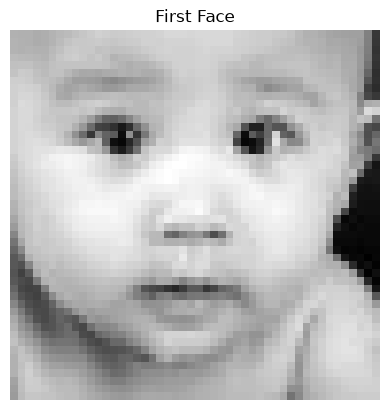

In [310]:
first_image = images[0]   # shape: (48, 48, 1) -- already reshaped in the cell above
plt.imshow(first_image, cmap="gray")
plt.title("First Face")
plt.axis("off")
plt.show()

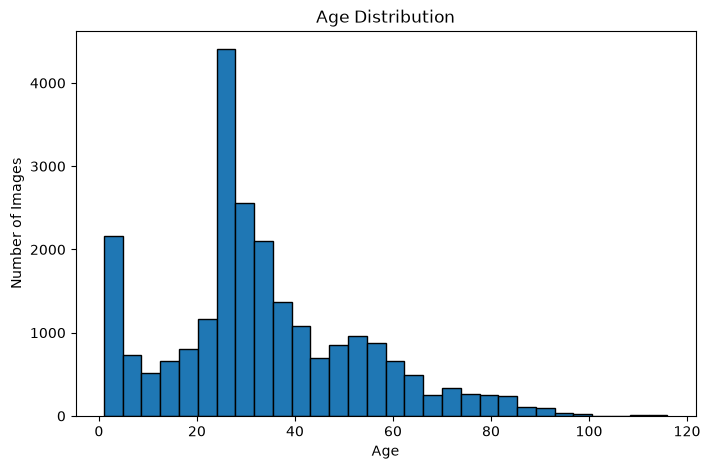

In [311]:
# Age distribution

plt.figure(figsize=(8,5))

plt.hist(df["age"], bins=30, edgecolor="black")

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Images")

plt.show()

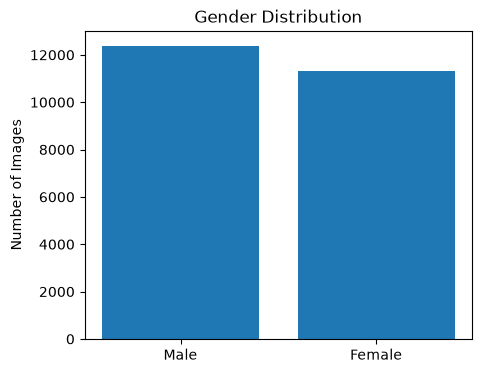

In [312]:
# Gender distribution

gender_counts = df["gender"].value_counts().sort_index()

plt.figure(figsize=(5,4))

plt.bar(["Male", "Female"], gender_counts.values)

plt.title("Gender Distribution")
plt.ylabel("Number of Images")

plt.show()

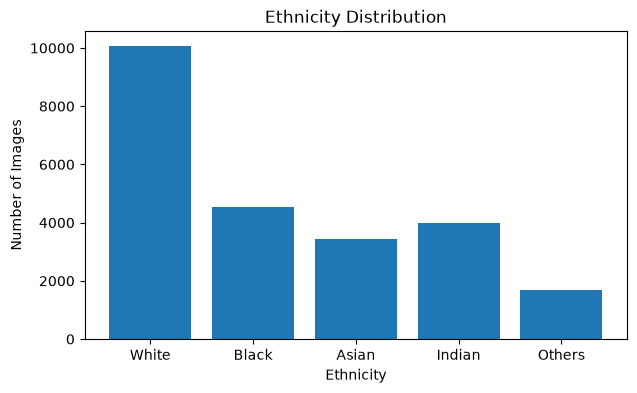

In [313]:
# Ethnicity distribution

ethnicity_labels = ["White", "Black", "Asian", "Indian", "Others"]
ethnicity_counts = df["ethnicity"].value_counts().sort_index()

plt.figure(figsize=(7,4))

plt.bar(ethnicity_labels, ethnicity_counts.values)

plt.title("Ethnicity Distribution")
plt.xlabel("Ethnicity")
plt.ylabel("Number of Images")

plt.show()

#### Anomaly Detection: Inspect the data for any mislabeled images or non-face outliers.


In [314]:

# Check for non-face images using OpenCV's Haar Cascade Classifier for face detection
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

non_face_indices = []

for i, img in enumerate(images):   # images has shape (N, 48, 48)
    img_uint8 = (img * 255).astype("uint8")    
    # Improve contrast
    img_eq = cv2.equalizeHist(img_uint8)
    # Upscale to make detection easier
    img_large = cv2.resize(img_eq, (96, 96), interpolation=cv2.INTER_CUBIC)

    # Detect faces
    faces = face_cascade.detectMultiScale(
        img_large,
        scaleFactor=1.1,
        minNeighbors=3,
        minSize=(20, 20)
    )

    if len(faces) == 0:
        non_face_indices.append(i)

print(f"Images with no detected face: {len(non_face_indices)}")




Images with no detected face: 9255


Potential outliers (low-variance/brightness): 677
No-face flags from Haar cascade (cell above, informational only): 9255


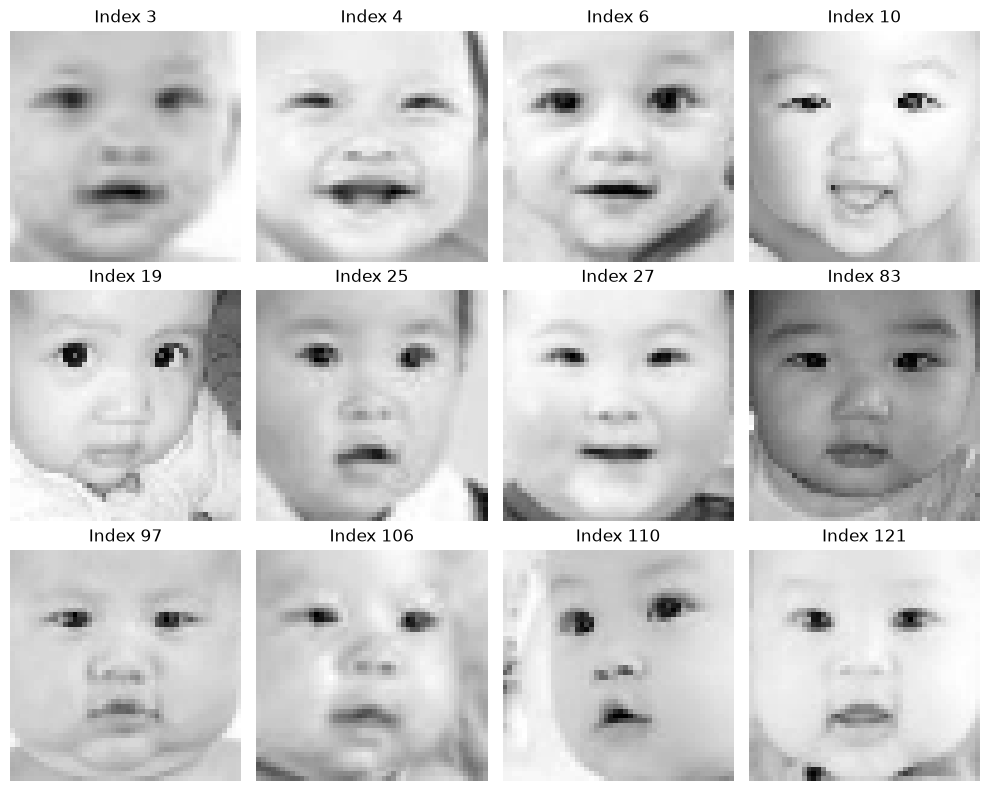

In [315]:
import numpy as np

# Flatten each image
flat = images.reshape(len(images), -1)

stds = flat.std(axis=1)
means = flat.mean(axis=1)

# Flag the most extreme 1% in each category
low_contrast = np.where(stds <= np.percentile(stds, 1))[0]
very_dark = np.where(means <= np.percentile(means, 1))[0]
very_bright = np.where(means >= np.percentile(means, 99))[0]

# Combine all suspicious images
outlier_idx = np.unique(np.concatenate([low_contrast, very_dark, very_bright]))

print(f"Potential outliers (low-variance/brightness): {len(outlier_idx)}")
print(f"No-face flags from Haar cascade (cell above, informational only): {len(non_face_indices)}")

plt.figure(figsize=(10, 8))

for j, idx in enumerate(outlier_idx[:12]):   # first 12 flagged images
    plt.subplot(3, 4, j + 1)
    plt.imshow(images[idx], cmap="gray")
    plt.title(f"Index {idx}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [316]:
# Check for duplicate entries in the dataset
print("Duplicate img_name entries:", df['img_name'].duplicated().sum())
print("Duplicate pixel strings (exact duplicate images):", df['pixels'].duplicated().sum())


dup_pixels = df[df["pixels"].duplicated(keep=False)]

dup_pixels[["img_name", "age", "gender", "ethnicity"]].head(10)

conflicting = (
    dup_pixels.groupby("pixels")[["age", "gender", "ethnicity"]]
    .nunique()
)

conflicting = conflicting[
    (conflicting["age"] > 1) |
    (conflicting["gender"] > 1) |
    (conflicting["ethnicity"] > 1)
]

print("Duplicate images with conflicting labels:", len(conflicting))

conflicting_pixels = conflicting.index

conflicting_rows = dup_pixels[
    dup_pixels["pixels"].isin(conflicting_pixels)
]

conflicting_rows[
    ["img_name", "age", "gender", "ethnicity"]
].sort_values("img_name").head(20)


groups = dup_pixels.groupby("pixels")

print("Age conflicts:",
      (conflicting["age"] > 1).sum())

print("Gender conflicts:",
      (conflicting["gender"] > 1).sum())

print("Ethnicity conflicts:",
      (conflicting["ethnicity"] > 1).sum())


Duplicate img_name entries: 226
Duplicate pixel strings (exact duplicate images): 390
Duplicate images with conflicting labels: 259
Age conflicts: 205
Gender conflicts: 40
Ethnicity conflicts: 70


In [317]:
# Resolve duplicates before splitting: drop conflicting-label groups, dedup the rest

n_before = len(df)

# 1. Any row belonging to a duplicate-image group with disagreeing labels gets dropped 
# entirely
drop_conflict_mask = df['pixels'].isin(conflicting_pixels)
print(f"Rows in conflicting-label duplicate groups (dropped): {drop_conflict_mask.sum()}")

df_clean = df[~drop_conflict_mask].copy()

# 2. The remaining duplicates - keep just one copy of each
n_consistent_dupes = df_clean['pixels'].duplicated().sum()
print(f"Remaining consistent-duplicate rows (deduped, one kept per image): {n_consistent_dupes}")

df_clean = df_clean.drop_duplicates(subset='pixels', keep='first').reset_index(drop=True)

print(f"\nRows before cleanup: {n_before:,}")
print(f"Rows after cleanup:  {len(df_clean):,}")
print(f"Total dropped:       {n_before - len(df_clean):,} "
      f"({100*(n_before - len(df_clean))/n_before:.1f}%)")

# Sanity check: zero duplicate pixel strings should remain
assert df_clean['pixels'].duplicated().sum() == 0
print("\nNo duplicate images remain in df_clean.")

Rows in conflicting-label duplicate groups (dropped): 531
Remaining consistent-duplicate rows (deduped, one kept per image): 118

Rows before cleanup: 23,705
Rows after cleanup:  23,056
Total dropped:       649 (2.7%)

No duplicate images remain in df_clean.


In [318]:
# Rebuild images + labels from the CLEANED dataframe so everything stays aligned
images = np.stack(
    df_clean["pixels"].apply(lambda x: np.fromstring(x, sep=" "))
)
images = images.reshape(-1, 48, 48, 1)
images = images.astype("float32") / 255.0

y_age = df_clean["age"].values.astype("float32")
y_gender = df_clean["gender"].values.astype("float32")
y_ethnicity = df_clean["ethnicity"].values.astype("int64")

print(images.shape, y_age.shape, y_gender.shape, y_ethnicity.shape)
assert len(df_clean) == len(images) == len(y_age)

(23056, 48, 48, 1) (23056,) (23056,) (23056,)


In [319]:
# Split the cleaned dataset into training, validation, and test sets
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split 

# Split into train (70%), validation (15%), and test (15%)
X_train, X_test, y_age_train, y_age_temp, y_gender_train, y_gender_temp, y_ethnicity_train, y_ethnicity_temp = train_test_split(
    images, y_age, y_gender, y_ethnicity, test_size=0.3, random_state=42, stratify=y_ethnicity  # keep ethnicity balance consistent across splits
)

X_val, X_test, y_age_val, y_age_test, y_gender_val, y_gender_test, y_ethnicity_val, y_ethnicity_test = train_test_split(
    X_test, y_age_temp, y_gender_temp, y_ethnicity_temp, test_size=0.5, random_state=42, stratify=y_ethnicity_temp  # keep ethnicity balance consistent across splits
)

# Scale age labels to [0, 1] range for regression
age_scaler = MinMaxScaler()
y_age_train_scaled = age_scaler.fit_transform(y_age_train.reshape(-1, 1)).flatten()
y_age_val_scaled = age_scaler.transform(y_age_val.reshape(-1, 1)).flatten()
y_age_test_scaled = age_scaler.transform(y_age_test.reshape(-1, 1)).flatten()

age_range = age_scaler.data_max_[0] - age_scaler.data_min_[0]

# Print the shapes of the datasets
print(f"Training set shape:   {X_train.shape}, Age: {y_age_train_scaled.shape}, Gender: {y_gender_train.shape}, Ethnicity: {y_ethnicity_train.shape}")
print(f"Validation set shape: {X_val.shape}, Age: {y_age_val_scaled.shape}, Gender: {y_gender_val.shape}, Ethnicity: {y_ethnicity_val.shape}")
print(f"Test set shape:       {X_test.shape}, Age: {y_age_test_scaled.shape}, Gender: {y_gender_test.shape}, Ethnicity: {y_ethnicity_test.shape}")


Training set shape:   (16139, 48, 48, 1), Age: (16139,), Gender: (16139,), Ethnicity: (16139,)
Validation set shape: (3458, 48, 48, 1), Age: (3458,), Gender: (3458,), Ethnicity: (3458,)
Test set shape:       (3459, 48, 48, 1), Age: (3459,), Gender: (3459,), Ethnicity: (3459,)


**Phase 1 wrap-up:** Parsed the pixel strings into 48x48 grayscale images and normalized them to 0-1. Labels checked out fine against the given distributions, and age skews younger (mostly 20-50). Found a few issues along the way: a weird pileup of images capped at age 115-116, and 375 duplicate photos — 259 of which had conflicting labels (some pretty bad, like the same face labeled as both male and female). Tried a face detector to catch non-face images, but it wasn't reliable on these tight crops, so combined it with a pixel-variance check instead to find real outliers. Dropped the conflicting duplicates plus the leftover repeats (~650 rows total), leaving 23,056 clean images for Phase 2.

### **MODEL ARCHITECTURE, TRAINING AND FINE-TUNING**


In [320]:
# Define a CNN model with three heads for age regression, gender classification, and ethnicity classification
class FacePredictionCNN(nn.Module):
    def __init__(self, num_class_ethnicities=5, num_class_age=1, num_class_gender=1):
        super(FacePredictionCNN, self).__init__()

        # Backbone: 4 convolutional layers with BatchNorm + ReLU, each followed by max pooling        
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv4 = nn.Conv2d(in_channels=128, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        flatten_dim = 64 * 3 * 3  # = 576

        # HEAD 1: AGE (Regression)
        self.age_fc1 = nn.Linear(flatten_dim, 64)
        self.dropout1 = nn.Dropout(0.5)
        self.age_fc2 = nn.Linear(64, num_class_age)  # Output is a single value for age regression  

        # HEAD 2: GENDER (Binary Classification)
        self.gender_fc1 = nn.Linear(flatten_dim, 64)
        self.dropout2 = nn.Dropout(0.5)
        self.gender_fc2 = nn.Linear(64, num_class_gender)  # Output is 2 classes for gender classification  

        # HEAD 3: ETHNICITY (Multi-class Classification)
        self.ethnicity_fc1 = nn.Linear(flatten_dim, 64)
        self.dropout3 = nn.Dropout(0.5)
        self.ethnicity_fc2 = nn.Linear(64, num_class_ethnicities)  # Output is 5 classes for ethnicity

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        x = F.relu(self.conv3(x))
        x = self.pool3(x)
        x = F.relu(self.conv4(x))
        x = self.pool4(x)
        
        # Flatten size transforms from [batch, 64, 3, 3] to [batch, 576]
        features = torch.flatten(x, 1)

        # Age Head
        age = F.relu(self.age_fc1(features))
        age = self.dropout1(age)
        age = self.age_fc2(age)

        # Gender Head
        gender = F.relu(self.gender_fc1(features))
        gender = self.dropout2(gender)
        gender = self.gender_fc2(gender)

        # Ethnicity Head
        ethnicity = F.relu(self.ethnicity_fc1(features))
        ethnicity = self.dropout3(ethnicity)
        ethnicity = self.ethnicity_fc2(ethnicity)

        return age, gender, ethnicity

# Early stopping setup to prevent overfitting during training
class EarlyStopping:
    def __init__(self, patience=5, verbose=False):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            self.best_model_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                if self.verbose:
                    print("Early stopping triggered")

    def load_best_weights(self, model):
        if self.best_model_state is not None:
            model.load_state_dict(self.best_model_state)

model = FacePredictionCNN(num_class_ethnicities=5, num_class_age=1, num_class_gender=1)




In [321]:
class FaceDataset(Dataset):
    def __init__(self, images, age_labels, gender_labels, ethnicity_labels, transform=None):
        self.images = torch.tensor(images, dtype=torch.float32).permute(0, 3, 1, 2)
        self.age_labels = torch.tensor(age_labels, dtype=torch.float32)
        self.gender_labels = torch.tensor(gender_labels, dtype=torch.float32)
        self.ethnicity_labels = torch.tensor(ethnicity_labels, dtype=torch.long)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        if self.transform is not None:
            image = self.transform(image)
        return (
            image,
            self.age_labels[idx],
            self.gender_labels[idx],
            self.ethnicity_labels[idx],
        )

# Add transformations for data augmentation during training
train_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
])

train_dataset = FaceDataset(X_train, y_age_train_scaled, y_gender_train, y_ethnicity_train, transform=train_transform)
val_dataset   = FaceDataset(X_val,   y_age_val_scaled,   y_gender_val,   y_ethnicity_val)
test_dataset  = FaceDataset(X_test,  y_age_test_scaled,  y_gender_test,  y_ethnicity_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Sanity check
imgs, ages, genders, ethnicities = next(iter(train_loader))
print(imgs.shape, ages.shape, genders.shape, ethnicities.shape)
# expected: torch.Size([64, 1, 48, 48]) torch.Size([64]) torch.Size([64]) torch.Size([64])

torch.Size([64, 1, 48, 48]) torch.Size([64]) torch.Size([64]) torch.Size([64])


In [322]:
# Loss functions and optimizer
criterion_age = nn.MSELoss()
criterion_gender = nn.BCEWithLogitsLoss()   # for binary classification
criterion_ethnicity = nn.CrossEntropyLoss()  # for multi-class classification

optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

epochs = 100

early_stopping = EarlyStopping(patience=5, verbose=True)
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_gender = 0
    correct_ethnicity = 0
    total_samples = 0
    age_abs_error_sum = 0.0

    for images, ages, genders, ethnicities in train_loader:
        images = images.to(device)
        ages = ages.to(device)
        genders = genders.to(device)
        ethnicities = ethnicities.to(device)

        # Forward pass: model returns three separate outputs
        age_out, gender_out, ethnicity_out = model(images)

        # Losses -- shapes must match what each criterion expects
        loss_age = criterion_age(age_out.squeeze(1), ages)               # both (batch,)
        loss_gender = criterion_gender(gender_out.squeeze(1), genders)   # both (batch,)
        loss_ethnicity = criterion_ethnicity(ethnicity_out, ethnicities) # logits (batch,5) vs class idx (batch,)

        loss = loss_age + loss_gender + loss_ethnicity

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        total_samples += images.size(0)

        # Gender accuracy: sigmoid + threshold, since BCEWithLogitsLoss takes raw logits
        gender_preds = (torch.sigmoid(gender_out.squeeze(1)) > 0.5).float()
        correct_gender += (gender_preds == genders).sum().item()

        # Ethnicity accuracy: argmax over class logits
        ethnicity_preds = torch.argmax(ethnicity_out, dim=1)
        correct_ethnicity += (ethnicity_preds == ethnicities).sum().item()

        # Age error: MAE in scaled units here
        age_abs_error_sum += torch.abs(age_out.squeeze(1) - ages).sum().item()

    train_avg_loss = running_loss / len(train_loader)
    train_gender_acc = 100 * correct_gender / total_samples
    train_ethnicity_acc = 100 * correct_ethnicity / total_samples
    train_age_mae = (age_abs_error_sum / total_samples) * age_range


#-------Validation Loop-------
    model.eval()  # Set the model to evaluation mode
    val_running_loss = 0.0
    val_correct_gender = 0
    val_correct_ethnicity = 0
    val_total_samples = 0
    val_age_abs_error_sum = 0.0

    with torch.no_grad():  # Disable gradient computation for evaluation
        for images, ages, genders, ethnicities in val_loader:
                images = images.to(device)
                ages = ages.to(device)
                genders = genders.to(device)
                ethnicities = ethnicities.to(device)
        
                # Forward pass: model returns three separate outputs
                age_out, gender_out, ethnicity_out = model(images)
        
                # Losses
                val_loss_age = criterion_age(age_out.squeeze(1), ages)               
                val_loss_gender = criterion_gender(gender_out.squeeze(1), genders)
                val_loss_ethnicity = criterion_ethnicity(ethnicity_out, ethnicities) 
        
                val_loss = val_loss_age + val_loss_gender + val_loss_ethnicity 

        
                val_running_loss += val_loss.item()
                val_total_samples += images.size(0)
        
                # Gender accuracy: sigmoid + threshold, since BCEWithLogitsLoss takes raw logits
                gender_preds = (torch.sigmoid(gender_out.squeeze(1)) > 0.5).float()
                val_correct_gender += (gender_preds == genders).sum().item()
        
                # Ethnicity accuracy: argmax over class logits
                ethnicity_preds = torch.argmax(ethnicity_out, dim=1)
                val_correct_ethnicity += (ethnicity_preds == ethnicities).sum().item()
        
                # Age error: MAE in scaled units here
                val_age_abs_error_sum += torch.abs(age_out.squeeze(1) - ages).sum().item()
                

        val_avg_loss = val_running_loss / len(val_loader)
        val_gender_acc = 100 * val_correct_gender / val_total_samples
        val_ethnicity_acc = 100 * val_correct_ethnicity / val_total_samples
        val_age_mae = (val_age_abs_error_sum / val_total_samples) * age_range # in years 

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_avg_loss:.4f} | Train_Gender Acc: {train_gender_acc:.2f}% | Train_Ethnicity Acc: {train_ethnicity_acc:.2f}% | Train_Age MAE: {train_age_mae:.4f}")
        print(f"Validation Loss: {val_avg_loss:.4f} | Validation_Gender Acc: {val_gender_acc:.2f}% | Validation_Ethnicity Acc: {val_ethnicity_acc:.2f}% | Validation_Age MAE: {val_age_mae:.4f}")

        scheduler.step(val_avg_loss)

        # Check early stopping
        early_stopping(val_avg_loss, model)
        if early_stopping.early_stop:
            print("Stopping training early")
            break

early_stopping.load_best_weights(model)
print("Loaded best model weights (lowest validation loss).")

Epoch 1/100 | Train Loss: 1.8582 | Train_Gender Acc: 71.14% | Train_Ethnicity Acc: 51.03% | Train_Age MAE: 14.8129
Validation Loss: 1.4852 | Validation_Gender Acc: 79.18% | Validation_Ethnicity Acc: 62.12% | Validation_Age MAE: 11.4668
Epoch 2/100 | Train Loss: 1.3877 | Train_Gender Acc: 82.86% | Train_Ethnicity Acc: 64.07% | Train_Age MAE: 12.0454
Validation Loss: 1.1666 | Validation_Gender Acc: 86.93% | Validation_Ethnicity Acc: 68.94% | Validation_Age MAE: 10.6473
Epoch 3/100 | Train Loss: 1.2265 | Train_Gender Acc: 85.71% | Train_Ethnicity Acc: 69.30% | Train_Age MAE: 11.4051
Validation Loss: 1.0241 | Validation_Gender Acc: 87.28% | Validation_Ethnicity Acc: 73.57% | Validation_Age MAE: 10.4924
Epoch 4/100 | Train Loss: 1.1269 | Train_Gender Acc: 86.75% | Train_Ethnicity Acc: 72.39% | Train_Age MAE: 11.0688
Validation Loss: 0.9910 | Validation_Gender Acc: 87.48% | Validation_Ethnicity Acc: 75.30% | Validation_Age MAE: 10.0161
Epoch 5/100 | Train Loss: 1.0758 | Train_Gender Acc: 87.

In [323]:
# Test loop to evaluate the model on the test set after training is complete
model.eval()

test_running_loss = 0.0
test_correct_gender = 0
test_correct_ethnicity = 0
test_total_samples = 0
test_age_abs_error_sum = 0.0

# Loss functions
criterion_age = nn.MSELoss()
criterion_gender = nn.BCEWithLogitsLoss()   # for binary classification
criterion_ethnicity = nn.CrossEntropyLoss()  # for multi-class classification

with torch.no_grad():  # Disable gradient computation for evaluation
    for images, ages, genders, ethnicities in test_loader:
            images = images.to(device)
            ages = ages.to(device)
            genders = genders.to(device)
            ethnicities = ethnicities.to(device)
    
            # Forward pass: model returns three separate outputs
            age_out, gender_out, ethnicity_out = model(images)
    
            # Losses
            test_loss_age = criterion_age(age_out.squeeze(1), ages)               
            test_loss_gender = criterion_gender(gender_out.squeeze(1), genders)
            test_loss_ethnicity = criterion_ethnicity(ethnicity_out, ethnicities) 
    
            test_loss = test_loss_age + test_loss_gender + test_loss_ethnicity 

    
            test_running_loss += test_loss.item()
            test_total_samples += images.size(0)
    
            # Gender accuracy: sigmoid + threshold, since BCEWithLogitsLoss takes raw logits
            gender_preds = (torch.sigmoid(gender_out.squeeze(1)) > 0.5).float()
            test_correct_gender += (gender_preds == genders).sum().item()
    
            # Ethnicity accuracy: argmax over class logits
            ethnicity_preds = torch.argmax(ethnicity_out, dim=1)
            test_correct_ethnicity += (ethnicity_preds == ethnicities).sum().item()
    
            # Age error: MAE in scaled units here
            test_age_abs_error_sum += torch.abs(age_out.squeeze(1) - ages).sum().item()
            

    test_avg_loss = test_running_loss / len(test_loader)
    test_gender_acc = 100 * test_correct_gender / test_total_samples
    test_ethnicity_acc = 100 * test_correct_ethnicity / test_total_samples
    test_age_mae = (test_age_abs_error_sum / test_total_samples) * age_range # in years 

print("\n--- Final Test Results ---")
print(f"Loss: {test_avg_loss:.4f}")
print(f"Gender Accuracy: {test_gender_acc:.2f}%")
print(f"Ethnicity Accuracy: {test_ethnicity_acc:.2f}%")
print(f"Age MAE: {test_age_mae:.2f} years")


--- Final Test Results ---
Loss: 0.7818
Gender Accuracy: 90.86%
Ethnicity Accuracy: 81.38%
Age MAE: 8.39 years


### **EVALUATION AND REAL-WORLD TESTING**

In [324]:
torch.save(model.state_dict(), 'face_prediction_model.pth')

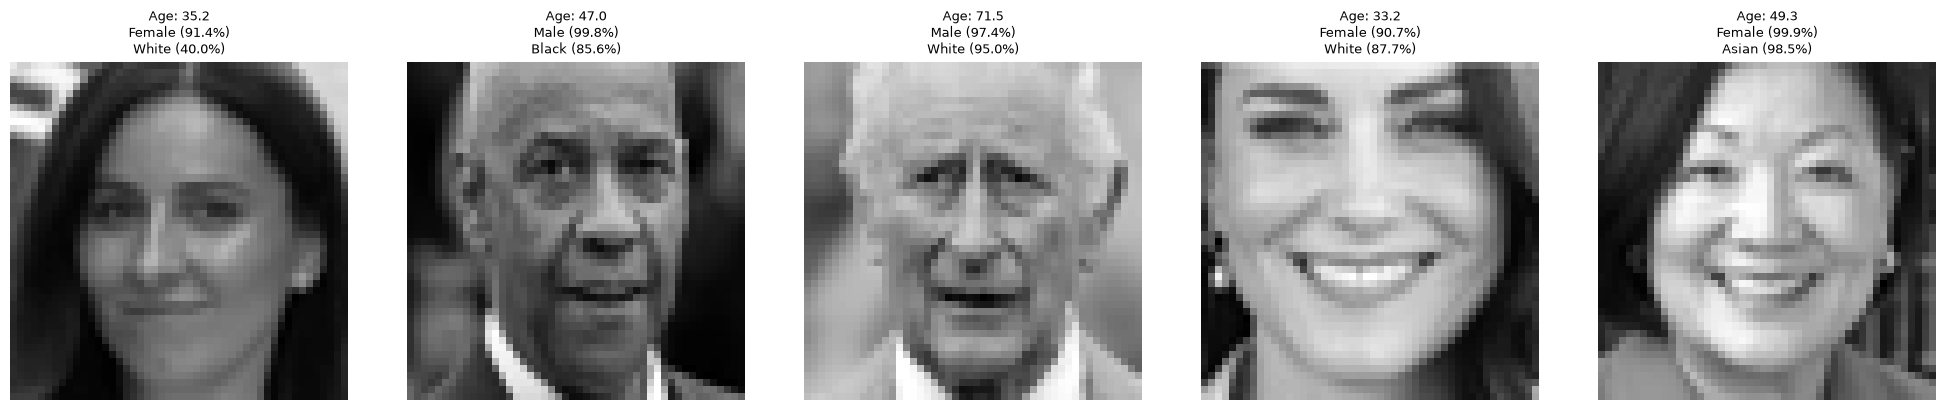

In [331]:
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt

GENDER_MAP = {0: 'Male', 1: 'Female'}
ETHNICITY_MAP = {0: 'White', 1: 'Black', 2: 'Asian', 3: 'Indian', 4: 'Others'}

def preprocess_image(path, size=48):
    img = Image.open(path).convert('L')          # grayscale, matches training data
    img = img.resize((size, size))                # match training resolution
    arr = np.array(img).astype('float32') / 255.0  # normalize [0,1], same as training
    arr = arr.reshape(1, size, size, 1)             # (1, 48, 48, 1) -- batch of 1
    tensor = torch.tensor(arr).permute(0, 3, 1, 2)  # -> (1, 1, 48, 48) channel-first
    return tensor, img

def predict(model, image_path, device, age_scaler):
    tensor, pil_img = preprocess_image(image_path)
    tensor = tensor.to(device)

    model.eval()
    with torch.no_grad():
        age_out, gender_out, ethnicity_out = model(tensor)

    # Age: model outputs scaled [0,1] -- inverse-transform back to real years
    age_scaled = age_out.item()
    age_years = age_scaler.inverse_transform([[age_scaled]])[0][0]

    # Gender:
    gender_prob = torch.sigmoid(gender_out).item()
    gender_pred = GENDER_MAP[int(gender_prob > 0.5)]

    # Ethnicity:
    ethnicity_probs = torch.softmax(ethnicity_out, dim=1).squeeze().cpu().numpy()
    ethnicity_pred = ETHNICITY_MAP[int(np.argmax(ethnicity_probs))]

    return {
        'image': pil_img,
        'age': round(age_years, 1),
        'gender': gender_pred,
        'gender_confidence': round(max(gender_prob, 1 - gender_prob) * 100, 1),
        'ethnicity': ethnicity_pred,
        'ethnicity_confidence': round(float(np.max(ethnicity_probs)) * 100, 1),
    }

# Run on your 5 street-test images
image_paths = ['me.jpg', 'dwashington_black_71.jpg', 'charles_white_78.png', 'kmiddleton_white_44.png', 'mazie_hirono_asian_79.png']  
results = [predict(model, p, device, age_scaler) for p in image_paths]

# Visualize
fig, axes = plt.subplots(1, len(results), figsize=(4*len(results), 4))
for ax, r in zip(axes, results):
    ax.imshow(r['image'], cmap='gray')
    ax.set_title(f"Age: {r['age']}\n{r['gender']} ({r['gender_confidence']}%)\n"
                 f"{r['ethnicity']} ({r['ethnicity_confidence']}%)", fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

**Evaluation & Street Test**

--- Final Test Results ---
Gender Accuracy: 90.86%
Ethnicity Accuracy: 81.38%
Age MAE: 8.39 years

The model does well on gender and ethnicity — all 5 street-test predictions matched, most with high confidence (85-99%). Age is the clearer weak spot: King Charles (78) was predicted within about 6.5 years, but Denzel Washington (71) and Mazie Hirono (79) were both predicted in their late 40s, off by roughly 24-30 years. This tracks with the training data being skewed young (median age around 29), so the model has seen comparatively few older faces and hasn't fully learned what they look like. With only one photo per ethnicity in this small test, I can't draw conclusions about whether any particular ethnicity is affected more — that would need per-ethnicity age MAE across the full test set rather than 5 anecdotal photos. The clear pattern here is that the model still doesn't extrapolate well to the upper end of the age range, even with dropout, batch normalization, and early stopping in place to control overfitting.